In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import rc
rc('animation', html='jshtml')

In [5]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/communities/communities.data'
data = pd.read_csv(url,sep=',',header=None)

In [7]:
data.columns = [ 'state', 'county', 'community', 'communityname', 'fold', 'population', 'householdsize', 'racepctblack', 'racePctWhite',
'racePctAsian', 'racePctHisp', 'agePct12t21', 'agePct12t29', 'agePct16t24', 'agePct65up', 'numbUrban', 'pctUrban', 'medIncome', 'pctWWage',
'pctWFarmSelf', 'pctWInvInc', 'pctWSocSec', 'pctWPubAsst', 'pctWRetire', 'medFamInc', 'perCapInc', 'whitePerCap', 'blackPerCap', 'indianPerCap',
'AsianPerCap', 'OtherPerCap', 'HispPerCap', 'NumUnderPov', 'PctPopUnderPov', 'PctLess9thGrade', 'PctNotHSGrad', 'PctBSorMore', 'PctUnemployed', 'PctEmploy',
'PctEmplManu', 'PctEmplProfServ', 'PctOccupManu', 'PctOccupMgmtProf', 'MalePctDivorce', 'MalePctNevMarr', 'FemalePctDiv', 'TotalPctDiv', 'PersPerFam', 'PctFam2Par',
'PctKids2Par', 'PctYoungKids2Par', 'PctTeen2Par', 'PctWorkMomYoungKids', 'PctWorkMom', 'NumIlleg', 'PctIlleg', 'NumImmig', 'PctImmigRecent', 'PctImmigRec5',
'PctImmigRec8', 'PctImmigRec10', 'PctRecentImmig', 'PctRecImmig5', 'PctRecImmig8', 'PctRecImmig10', 'PctSpeakEnglOnly', 'PctNotSpeakEnglWell', 'PctLargHouseFam', 'PctLargHouseOccup',
'PersPerOccupHous', 'PersPerOwnOccHous', 'PersPerRentOccHous', 'PctPersOwnOccup', 'PctPersDenseHous', 'PctHousLess3BR', 'MedNumBR', 'HousVacant', 'PctHousOccup', 'PctHousOwnOcc',
'PctVacantBoarded', 'PctVacMore6Mos', 'MedYrHousBuilt', 'PctHousNoPhone', 'PctWOFullPlumb', 'OwnOccLowQuart', 'OwnOccMedVal', 'OwnOccHiQuart', 'RentLowQ', 'RentMedian',
'RentHighQ', 'MedRent', 'MedRentPctHousInc', 'MedOwnCostPctInc', 'MedOwnCostPctIncNoMtg', 'NumInShelters', 'NumStreet', 'PctForeignBorn', 'PctBornSameState', 'PctSameHouse85',
'PctSameCity85', 'PctSameState85', 'LemasSwornFT', 'LemasSwFTPerPop', 'LemasSwFTFieldOps', 'LemasSwFTFieldPerPop', 'LemasTotalReq', 'LemasTotReqPerPop', 'PolicReqPerOffic', 'PolicPerPop',
'RacialMatchCommPol', 'PctPolicWhite', 'PctPolicBlack', 'PctPolicHisp', 'PctPolicAsian', 'PctPolicMinor', 'OfficAssgnDrugUnits', 'NumKindsDrugsSeiz', 'PolicAveOTWorked', 'LandArea',
'PopDens', 'PctUsePubTrans', 'PolicCars', 'PolicOperBudg', 'LemasPctPolicOnPatr', 'LemasGangUnitDeploy', 'LemasPctOfficDrugUn', 'PolicBudgPerPop', 'ViolentCrimesPerPop',
 ]

In [8]:
data

,state,county,community,communityname,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,ViolentCrimesPerPop
0,8,?,?,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
1,53,?,?,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,?,?,?,?,0.00,?,0.67
2,24,?,?,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,?,?,?,?,0.00,?,0.43
3,34,5,81440,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,?,?,?,?,0.00,?,0.12
4,42,95,6096,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,0.04,0.09,0.02,?,?,?,?,0.00,?,0.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989,12,?,?,TempleTerracecity,10,0.01,0.40,0.10,0.87,0.12,...,0.01,0.28,0.05,?,?,?,?,0.00,?,0.09
1990,6,?,?,Seasidecity,10,0.05,0.96,0.46,0.28,0.83,...,0.02,0.37,0.20,?,?,?,?,0.00,?,0.45
1991,9,9,80070,Waterburytown,10,0.16,0.37,0.25,0.69,0.04,...,0.08,0.32,0.18,0.08,0.06,0.78,0,0.91,0.28,0.23
1992,25,17,72600,Walthamcity,10,0.08,0.51,0.06,0.87,0.22,...,0.03,0.38,0.33,0.02,0.02,0.79,0,0.22,0.18,0.19


In [13]:
numericdataset = data._get_numeric_data()
dataMat = numericdataset.drop(['fold','state'], axis=1).values
dataMat

array([[0.19, 0.33, 0.02, ..., 0.2 , 0.32, 0.2 ],
       [0.  , 0.16, 0.12, ..., 0.45, 0.  , 0.67],
       [0.  , 0.42, 0.49, ..., 0.02, 0.  , 0.43],
       ...,
       [0.16, 0.37, 0.25, ..., 0.18, 0.91, 0.23],
       [0.08, 0.51, 0.06, ..., 0.33, 0.22, 0.19],
       [0.2 , 0.78, 0.14, ..., 0.05, 1.  , 0.48]])

In [29]:
mean= np.mean(dataMat, axis=0)
dataMatM = dataMat - mean
cov = dataMatM.T @ dataMatM
cov = cov/(len(dataMat)-1)
cov

array([[ 0.01610509, -0.00095881,  0.00743543, ...,  0.0078588 ,
         0.01422331,  0.01085579],
       [-0.00095881,  0.02680317, -0.00278454, ..., -0.00193146,
        -0.00371296, -0.00133207],
       [ 0.00743543, -0.00278454,  0.06423288, ...,  0.008535  ,
         0.0158847 ,  0.03727496],
       ...,
       [ 0.0078588 , -0.00193146,  0.008535  , ...,  0.0524661 ,
         0.01137541,  0.00820928],
       [ 0.01422331, -0.00371296,  0.0158847 , ...,  0.01137541,
         0.05775768,  0.01952064],
       [ 0.01085579, -0.00133207,  0.03727496, ...,  0.00820928,
         0.01952064,  0.05428196]])

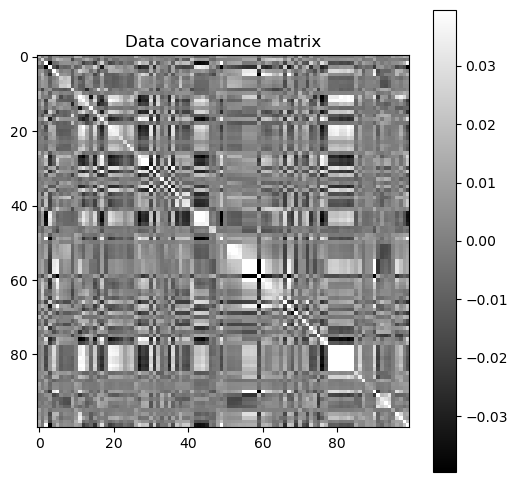

In [30]:
clim = np.max(np.abs(cov)) * .2
plt.figure(figsize=(6,6))
plt.imshow(cov,vmin=-clim,vmax=clim,cmap='gray')
plt.colorbar()
plt.title('Data covariance matrix')
plt.savefig('Figure_07_01.png',dpi=300)
plt.show()

In [63]:
#transformation
theta = np.pi//2
tmat = np.array([[np.cos(theta), -np.sin(theta)],[np.sin(theta), np.cos(theta)]])
v = np.diagonal(cov)
sr = np.sqrt(v)
s = np.diag(1/sr)
R = s @ cov @ s
R

array([[ 1.        , -0.04614841,  0.23117774, ...,  0.27035553,
         0.46635229,  0.36715738],
       [-0.04614841,  1.        , -0.06710914, ..., -0.05150557,
        -0.09436752, -0.0349226 ],
       [ 0.23117774, -0.06710914,  1.        , ...,  0.14702299,
         0.26079264,  0.63126363],
       ...,
       [ 0.27035553, -0.05150557,  0.14702299, ...,  1.        ,
         0.20664393,  0.15382885],
       [ 0.46635229, -0.09436752,  0.26079264, ...,  0.20664393,
         1.        ,  0.34862726],
       [ 0.36715738, -0.0349226 ,  0.63126363, ...,  0.15382885,
         0.34862726,  1.        ]])

In [69]:
np_cov = np.corrcoef(dataMat.T)

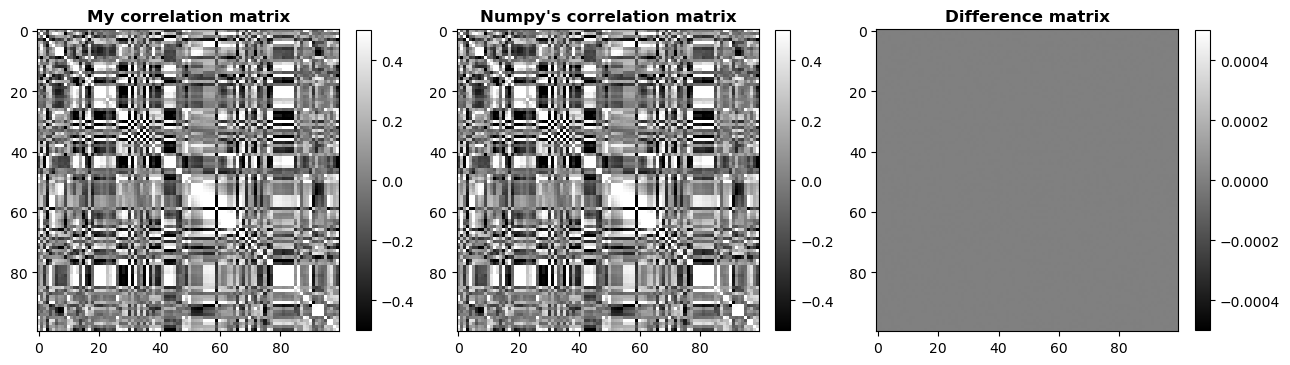

In [67]:
# and show it
fig,axs = plt.subplots(1,3,figsize=(13,6))
h1 = axs[0].imshow(R,vmin=-.5,vmax=.5,cmap='gray')
axs[0].set_title('My correlation matrix',fontweight='bold')

h2 = axs[1].imshow(np_cov,vmin=-.5,vmax=.5,cmap='gray')
axs[1].set_title("Numpy's correlation matrix",fontweight='bold')

h3 = axs[2].imshow(np_cov-R,vmin=-.0005,vmax=.0005,cmap='gray')
axs[2].set_title('Difference matrix',fontweight='bold')

fig.colorbar(h1,ax=axs[0],fraction=.045)
fig.colorbar(h2,ax=axs[1],fraction=.045)
fig.colorbar(h3,ax=axs[2],fraction=.045)

plt.tight_layout()
plt.savefig('Figure_07_07.png',dpi=300)
plt.show()
     

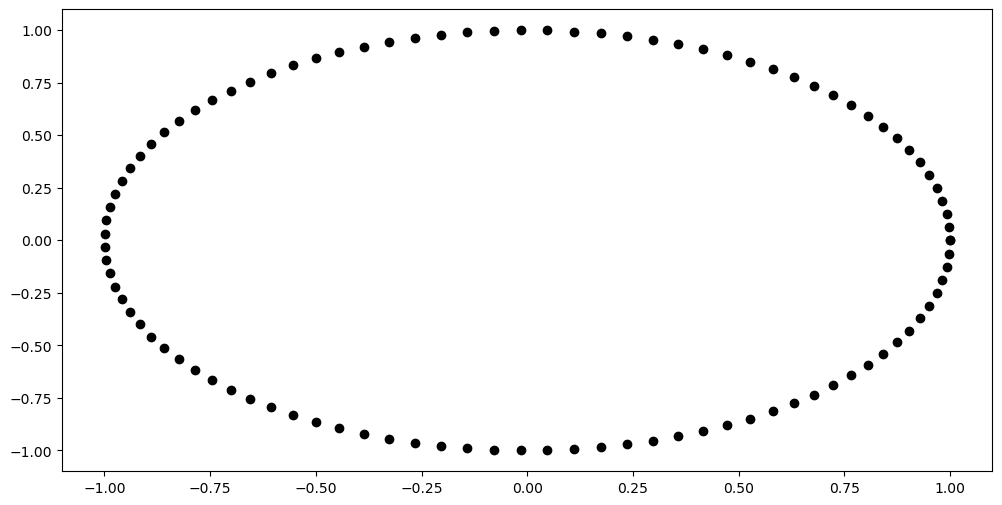

In [72]:
theta = np.linspace(0,2*np.pi,100)
points = np.vstack((np.sin(theta),np.cos(theta)))

fig,ax = plt.subplots(1,figsize=(12,6))
plth, = ax.plot(np.cos(theta),np.sin(theta),'ko')

In [78]:
def aframe(ph):
    T = np.array([[1,1-ph],[0,1] ])
    # theta = np.pi/2

    # T = np.array([[np.cos(theta), -np.sin(theta)],[np.sin(theta), np.cos(theta)]])

    P = T@points
    plth.set_xdata(P[0,:])
    plth.set_ydata(P[1,:])
    return plth

phi = np.linspace(-1,1-1/40,40)**2
animation.FuncAnimation(fig,aframe, phi, interval=100, repeat=True)